In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### Function Defining

In [2]:
def plot_eda_vertical(
    df,
    variables,
    kind="box",
    logy=True,
    title_prefix="",
    save_path=None,      # <-- ΝΕΟ
    dpi=300              # <-- ΝΕΟ (για publication quality)
):
    n = len(variables)
    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(10, 4*n),
        sharex=False
    )

    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):

        if kind == "box":
            sns.boxplot(data=df, x="injury", y=var, ax=ax)

        elif kind == "violin":
            sns.violinplot(data=df, x="injury", y=var, inner="quartile", ax=ax)

        elif kind == "kde":
            sns.kdeplot(data=df, x=var, hue="injury", common_norm=False, ax=ax)

        if logy and kind != "kde":
            ax.set_yscale("log")

        ax.set_title(f"{title_prefix}{var}", fontsize=14)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # 🔥 SAVE
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

### Loading Datasets

In [3]:
master_session_2020 = pd.read_csv('D:/PhD EMP/2020/master_session.csv').drop("Unnamed: 0", axis=1)

### Data Inspection

In [4]:
master_session_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3515 entries, 0 to 3514
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   player_name         3515 non-null   object 
 1   team                3515 non-null   object 
 2   session_id          3515 non-null   object 
 3   total_minutes       3515 non-null   int64  
 4   speed_mean_sess     3515 non-null   float64
 5   speed_sum_sess      3515 non-null   float64
 6   hr_mean_sess        3515 non-null   float64
 7   hr_sum_sess         3515 non-null   float64
 8   inst_acc_mean_sess  3515 non-null   float64
 9   inst_acc_sum_sess   3515 non-null   float64
 10  hacc_mean_sess      3515 non-null   float64
 11  hacc_sum_sess       3515 non-null   float64
 12  accl_x_mean_sess    3515 non-null   float64
 13  accl_x_sum_sess     3515 non-null   float64
 14  accl_y_mean_sess    3515 non-null   float64
 15  accl_y_sum_sess     3515 non-null   float64
 16  accl_z

### Data Inspection

In [5]:
master_session_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3515 entries, 0 to 3514
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   player_name         3515 non-null   object 
 1   team                3515 non-null   object 
 2   session_id          3515 non-null   object 
 3   total_minutes       3515 non-null   int64  
 4   speed_mean_sess     3515 non-null   float64
 5   speed_sum_sess      3515 non-null   float64
 6   hr_mean_sess        3515 non-null   float64
 7   hr_sum_sess         3515 non-null   float64
 8   inst_acc_mean_sess  3515 non-null   float64
 9   inst_acc_sum_sess   3515 non-null   float64
 10  hacc_mean_sess      3515 non-null   float64
 11  hacc_sum_sess       3515 non-null   float64
 12  accl_x_mean_sess    3515 non-null   float64
 13  accl_x_sum_sess     3515 non-null   float64
 14  accl_y_mean_sess    3515 non-null   float64
 15  accl_y_sum_sess     3515 non-null   float64
 16  accl_z

### Is there signal in the data

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

In [7]:
MECHANICAL_VARS = [
    "total_minutes",
    "speed_mean_sess","speed_sum_sess",
    "hr_mean_sess","hr_sum_sess",
    "inst_acc_mean_sess","inst_acc_sum_sess",
    "hacc_mean_sess","hacc_sum_sess",
    "accl_x_mean_sess","accl_x_sum_sess",
    "accl_y_mean_sess","accl_y_sum_sess",
    "accl_z_mean_sess","accl_z_sum_sess",
    "gyro_x_mean_sess","gyro_x_sum_sess",
    "gyro_y_mean_sess","gyro_y_sum_sess",
    "gyro_z_mean_sess","gyro_z_sum_sess",
]

SUBJECTIVE_VARS = [
    "srpe_sum","duration_sum","rpe_mean","rpe_max","n_sessions",
    "atl","ctl28","ctl42","daily_load","monotony","strain","weekly_load","acwr",
    "sleep_duration","sleep_quality",
    "fatigue","mood","readiness","soreness","stress"
]

In [8]:
### EXOUME 24 TRAYMATISMOUS
master_session_2020['injury'].value_counts()             

0    3491
1      24
Name: injury, dtype: int64

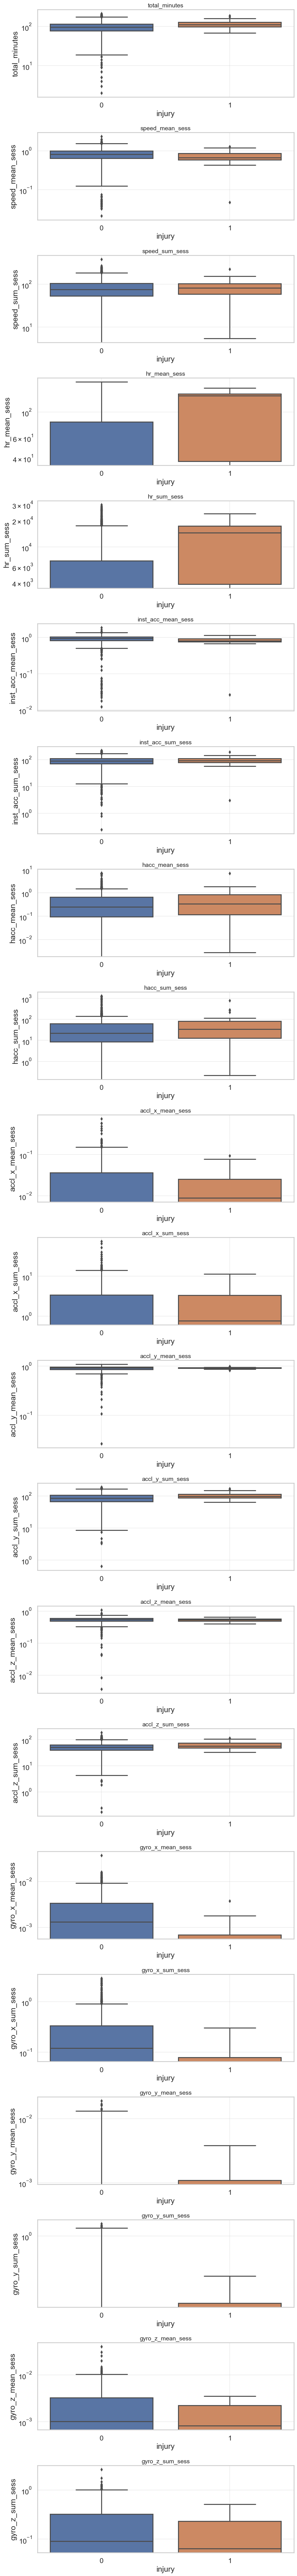

In [9]:
plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/mechanical_sum.png"
                 )

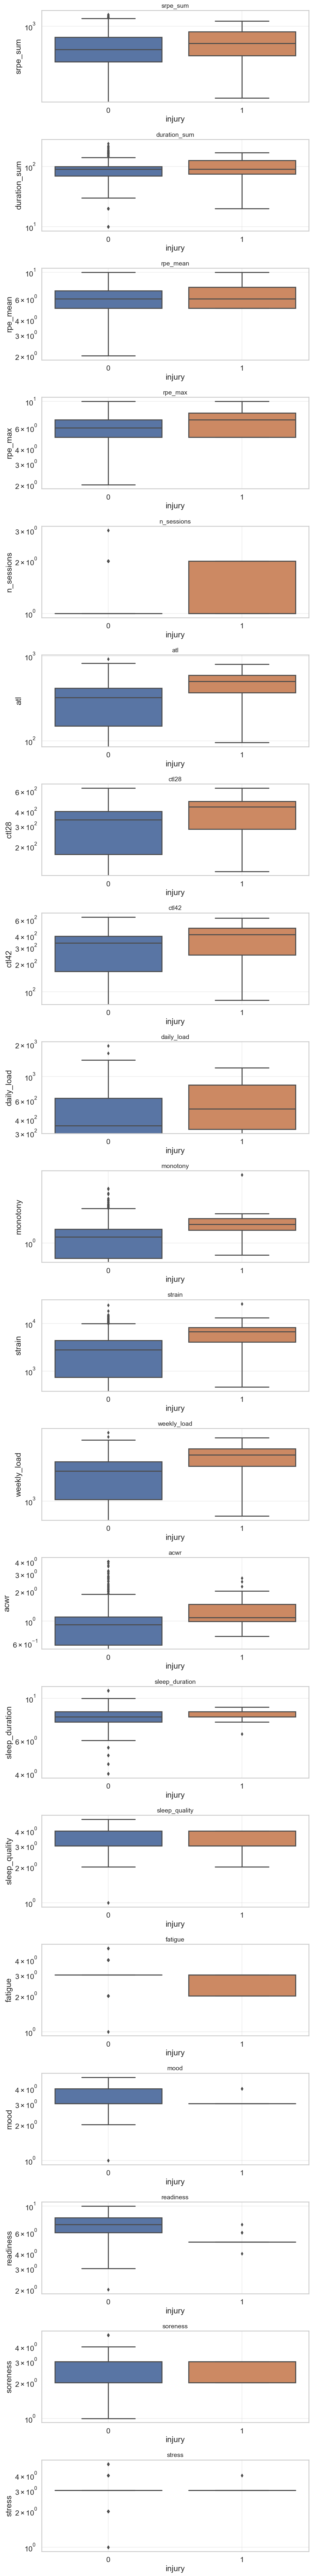

In [10]:
plot_eda_vertical(df=master_session_2020, variables = SUBJECTIVE_VARS,
                  save_path="eda_plots/subjective_sum.png"
                 )

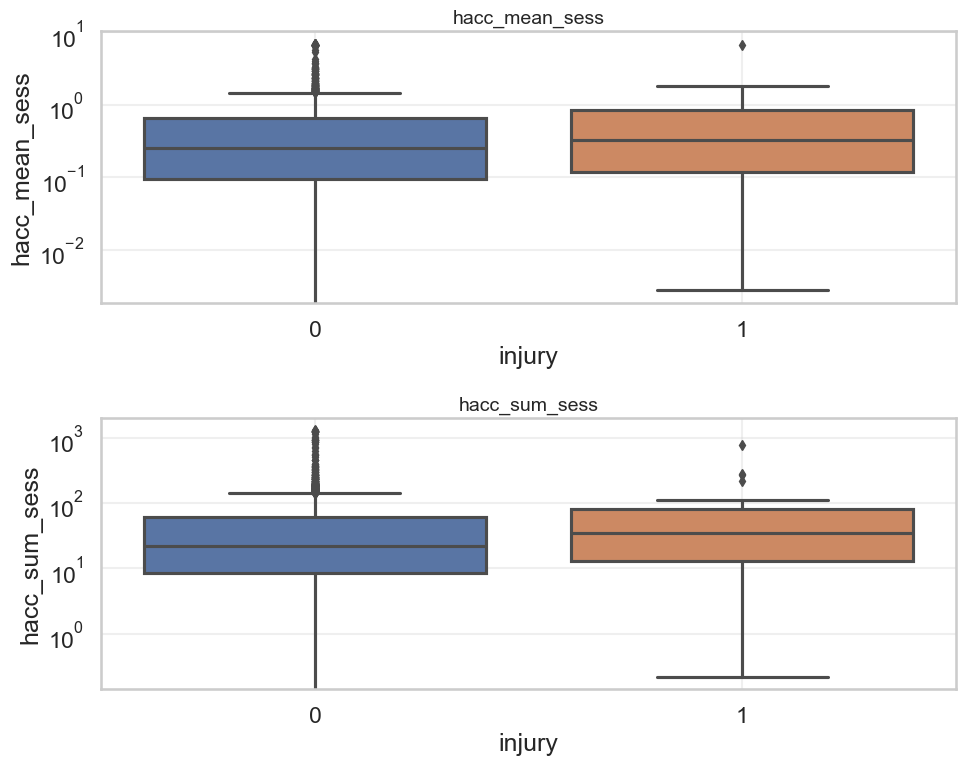

In [11]:
MECHANICAL_VARS = [
    "hacc_mean_sess","hacc_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/hacc_plot.png"
                 )

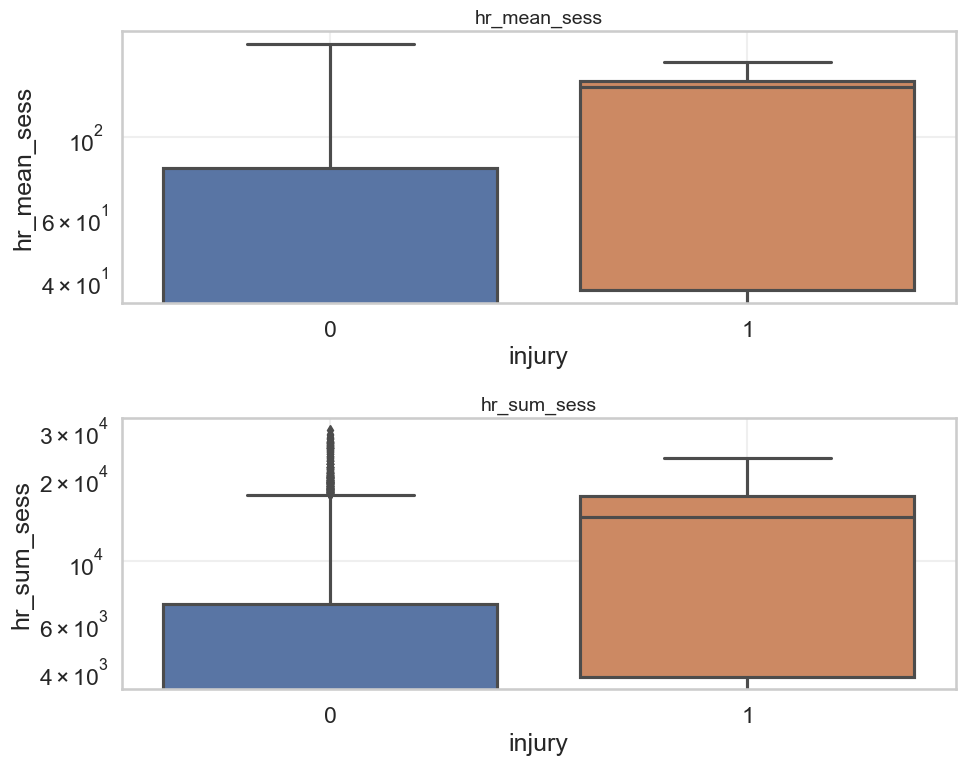

In [12]:
MECHANICAL_VARS = [
    "hr_mean_sess","hr_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/heart_rate.png"
                 )

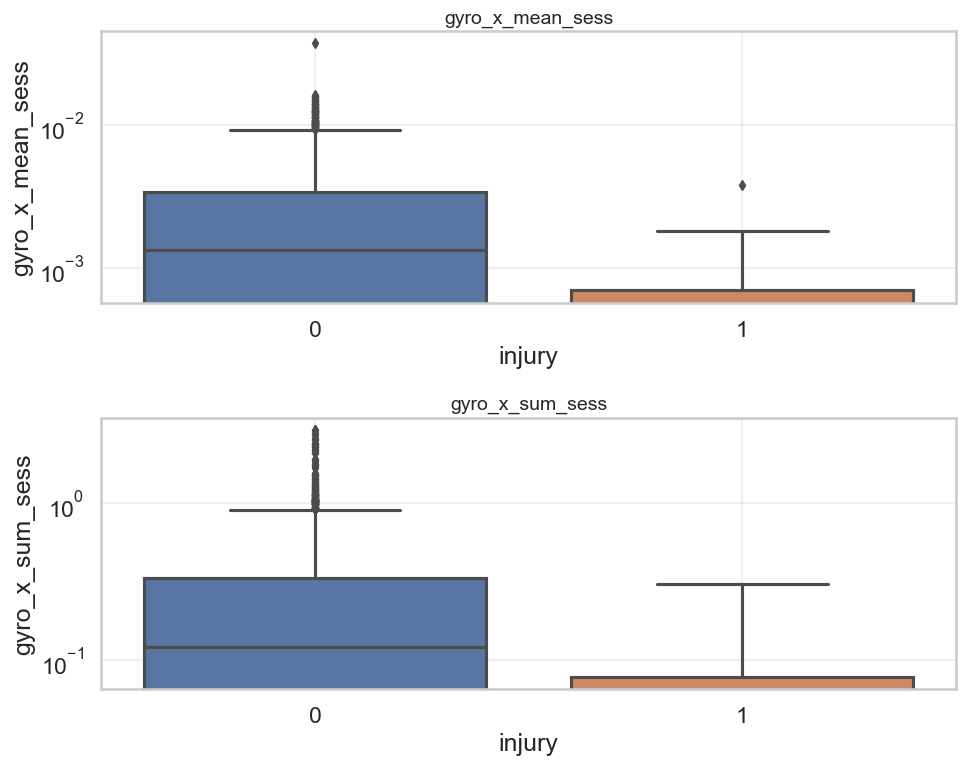

In [13]:
MECHANICAL_VARS = [
    "gyro_x_mean_sess","gyro_x_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/gyroscopic.png"
                 )

In [14]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_eda_vertical(
    df,
    variables,
    kind="box",
    logy=True,
    title_prefix="",
    save_path=None,
    dpi=300,
    figsize_per_plot=4,
    clip_outliers=False,
    lower_pct=1,
    upper_pct=99
):
    n = len(variables)
    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(10, max(figsize_per_plot * n, 4)),
        sharex=False
    )

    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        if var not in df.columns:
            ax.set_visible(False)
            continue

        plot_df = df[["injury", var]].copy()
        plot_df = plot_df.dropna()

        if plot_df.empty:
            ax.set_title(f"{title_prefix}{var} (no data)", fontsize=14)
            ax.set_visible(False)
            continue

        # Log scale cannot handle <= 0
        if logy and kind != "kde":
            plot_df = plot_df[plot_df[var] > 0]

        if plot_df.empty:
            ax.set_title(f"{title_prefix}{var} (no positive values for log scale)", fontsize=14)
            ax.set_visible(False)
            continue

        if kind == "box":
            sns.boxplot(data=plot_df, x="injury", y=var, ax=ax)

        elif kind == "violin":
            sns.violinplot(data=plot_df, x="injury", y=var, inner="quartile", ax=ax)

        elif kind == "kde":
            sns.kdeplot(data=plot_df, x=var, hue="injury", common_norm=False, ax=ax)

        else:
            raise ValueError("kind must be one of: 'box', 'violin', 'kde'")

        if logy and kind != "kde":
            ax.set_yscale("log")

        # Optional clipping to make the box visible when extreme outliers exist
        if clip_outliers and kind != "kde":
            y = plot_df[var].values
            y_low = np.percentile(y, lower_pct)
            y_high = np.percentile(y, upper_pct)

            if logy:
                y_low = max(y_low, np.min(y[y > 0]))

            if y_low < y_high:
                ax.set_ylim(y_low, y_high)

        ax.set_title(f"{title_prefix}{var}", fontsize=14)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

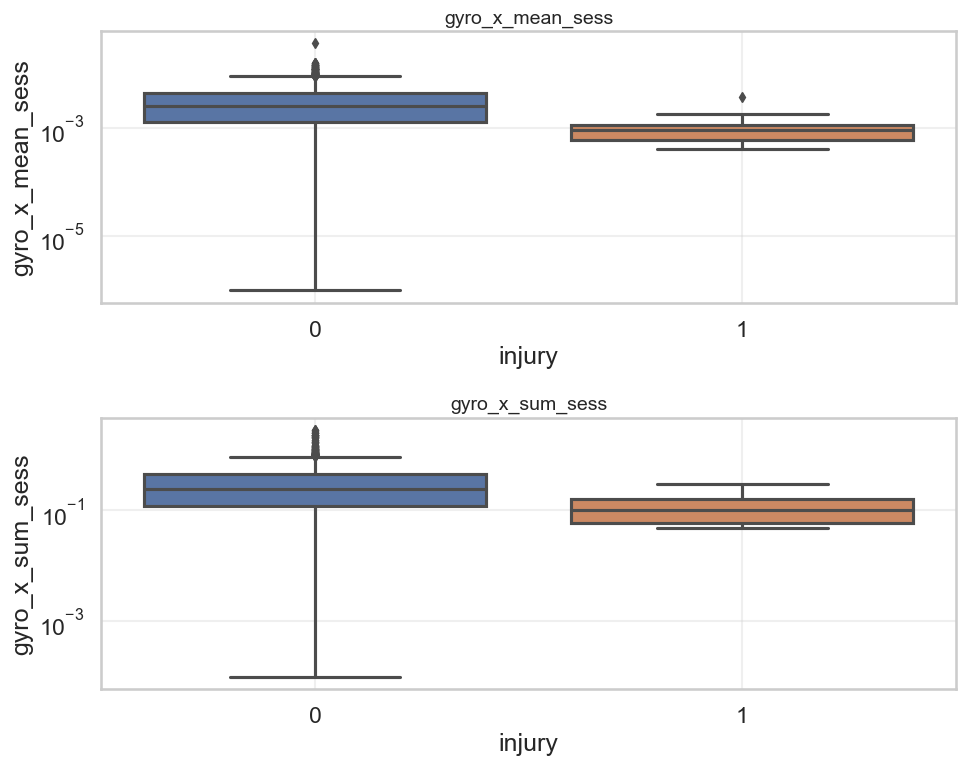

In [15]:
MECHANICAL_VARS = [
    "gyro_x_mean_sess","gyro_x_sum_sess",
]

plot_eda_vertical(master_session_2020, MECHANICAL_VARS, kind="box", logy=True,
                 save_path="eda_plots/gyroscopic.png")

In [16]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_eda_vertical(
    df,
    variables,
    kind="box",
    logy=True,
    title_prefix="",
    save_path=None,
    dpi=300,
    showfliers=False
):
    n = len(variables)
    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(10, 4 * n),
        sharex=False
    )

    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        plot_df = df[["injury", var]].copy().dropna()

        if plot_df.empty:
            ax.set_title(f"{title_prefix}{var} (no data)", fontsize=14)
            ax.grid(True, alpha=0.3)
            continue

        if logy and kind != "kde":
            plot_df = plot_df[plot_df[var] > 0]

        if plot_df.empty:
            ax.set_title(f"{title_prefix}{var} (no positive values)", fontsize=14)
            ax.grid(True, alpha=0.3)
            continue

        if kind == "box":
            sns.boxplot(
                data=plot_df,
                x="injury",
                y=var,
                ax=ax,
                showfliers=showfliers
            )

        elif kind == "violin":
            sns.violinplot(
                data=plot_df,
                x="injury",
                y=var,
                inner="quartile",
                ax=ax
            )

        elif kind == "kde":
            sns.kdeplot(
                data=plot_df,
                x=var,
                hue="injury",
                common_norm=False,
                ax=ax
            )

        else:
            raise ValueError("kind must be one of: 'box', 'violin', 'kde'")

        if logy and kind != "kde":
            ax.set_yscale("log")

        ax.set_title(f"{title_prefix}{var}", fontsize=14)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

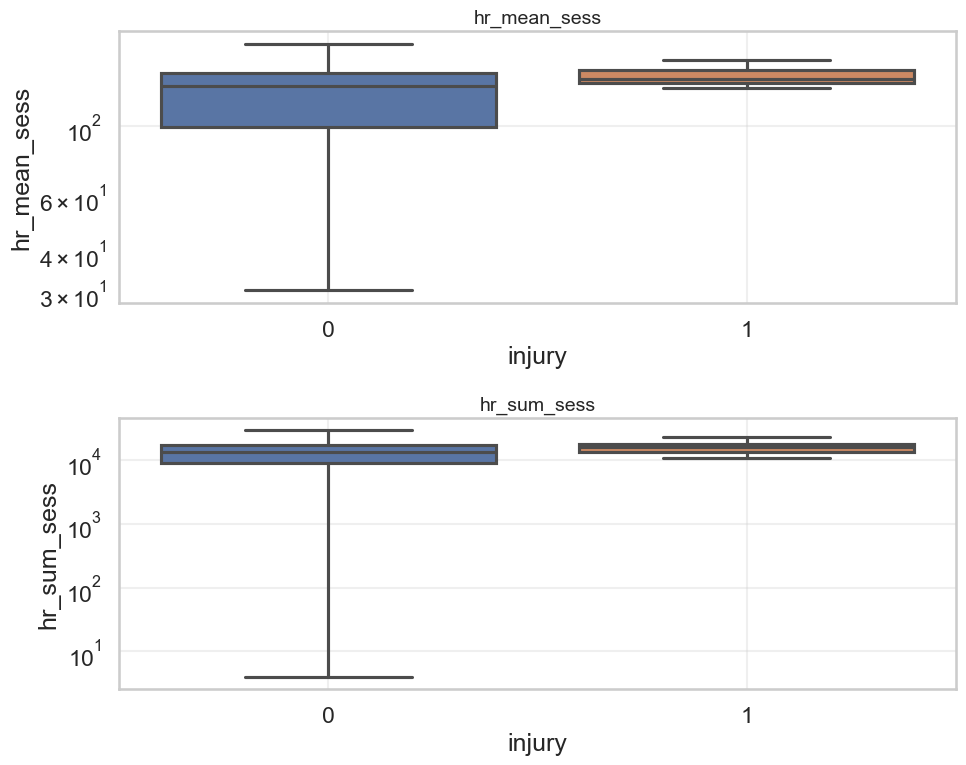

In [17]:
MECHANICAL_VARS = [
    "hr_mean_sess","hr_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/heart_rate.png",
                  showfliers=False
                 )

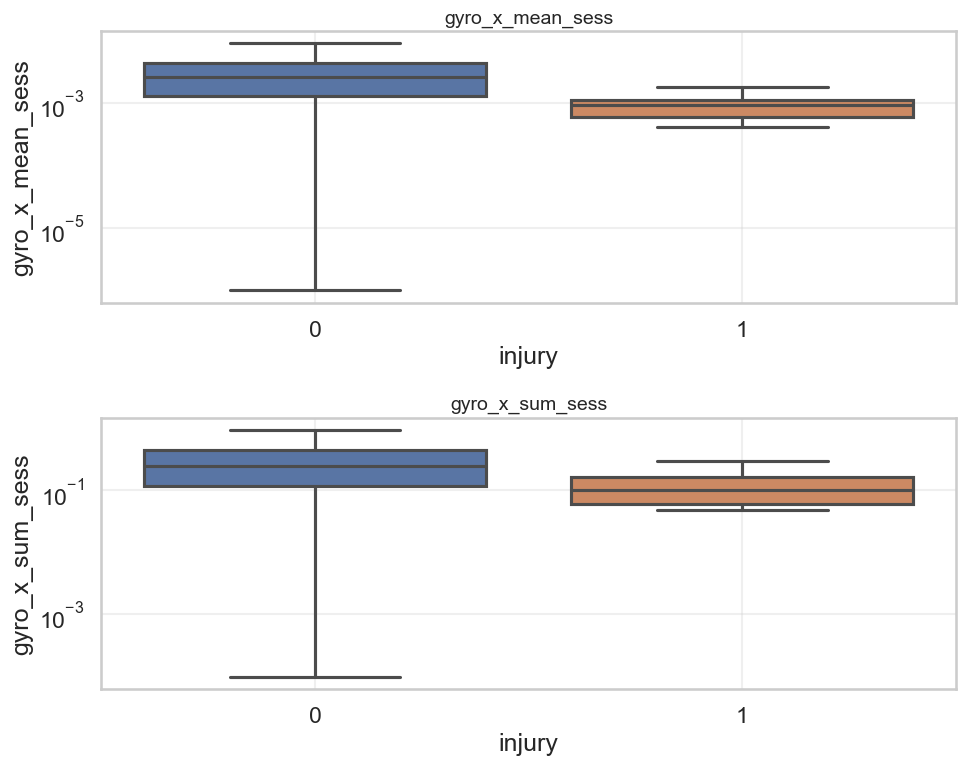

In [18]:
MECHANICAL_VARS = [
    "gyro_x_mean_sess","gyro_x_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/gyroscopic.png"
                 )

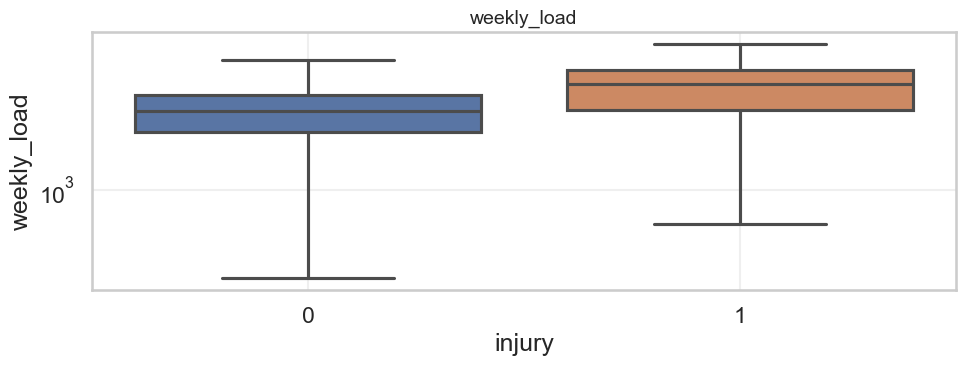

In [19]:
subjective = [
    "weekly_load"
]


plot_eda_vertical(df=master_session_2020, variables = subjective,
                  save_path="eda_plots/weekly_load.png"
                 )

### FINAL NOTES, FINDINGS, JUSTIFICATIONS

Η ανάλυση σε επίπεδο session ανέδειξε την ύπαρξη στατιστικού σήματος μεταξύ μηχανικού φορτίου, υποκειμενικών μεταβλητών και της εμφάνισης τραυματισμού, παρά την αναμενόμενη επικάλυψη των κατανομών. Το εύρημα αυτό υποδηλώνει ότι ο τραυματισμός δεν σχετίζεται με μία μεμονωμένη τιμή ή γεγονός, αλλά με τη συνολική δυναμική του φορτίου μέσα στη διάρκεια της προπονητικής ή αγωνιστικής έκθεσης. Ωστόσο, το session-level aggregation συμπυκνώνει έντονα τη χρονική πληροφορία, αποκρύπτοντας ενδο-συνεδριακές διακυμάνσεις, αιχμές έντασης και μεταβατικά μοτίβα που ενδέχεται να είναι κρίσιμα για την κατανόηση του μηχανισμού τραυματισμού.

Τα αποτελέσματα του EDA υποδεικνύουν ότι το σήμα τραυματισμού προκύπτει από τη συσσώρευση μικρών αποκλίσεων στο μηχανικό φορτίο, οι οποίες εκδηλώνονται σε επίπεδο λεπτού μέσω αυξημένης μεταβλητότητας, αιχμών έντασης και αστάθειας στην κίνηση. Μεταβλητές όπως τα accelerometer και gyroscope features, καθώς και τα minute-level speed και heart rate patterns, είναι πιθανό να περιέχουν πρώιμες ενδείξεις κόπωσης ή νευρομυϊκής απορρύθμισης που εξομαλύνονται όταν γίνεται απλή χρονική άθροιση σε επίπεδο session. Συνεπώς, το session-level σήμα που παρατηρείται στην EDA λειτουργεί ως ένδειξη ύπαρξης υποκείμενης χρονικής δομής, η οποία δικαιολογεί τη μετάβαση σε λεπτομερέστερη ανάλυση.

Με βάση τα παραπάνω, το minute-level modelling αποτελεί φυσική και αναγκαία επέκταση της ανάλυσης, καθώς επιτρέπει τη μοντελοποίηση της χρονικής εξέλιξης του φορτίου και τη σύλληψη μη γραμμικών και μη στατικών μοτίβων που προηγούνται του τραυματισμού. Η ύπαρξη σήματος σε επίπεδο session επιβεβαιώνει ότι τα δεδομένα περιέχουν προγνωστική πληροφορία, ενώ το minute-level granularity προσφέρει τη δυνατότητα εντοπισμού των κρίσιμων χρονικών παραθύρων στα οποία αυτή η πληροφορία εκδηλώνεται. Έτσι, το minute-level modelling δεν έρχεται σε αντίθεση με την EDA, αλλά αποτελεί τη μεθοδολογικά συνεπή συνέχεια μιας ανάλυσης που ήδη καταδεικνύει πολυπαραγοντική και χρονικά εξαρτώμενη φύση του τραυματισμού.